# Week 1: Foundations of Differential Equations in Physics (Part 1)

Welcome to the first week of our PINNs course! As a reminder, Weeks 1-2 focus on reviewing key differential equations from physics and introducing classical numerical methods for solving them. This week, we'll cover ordinary differential equations (ODEs) briefly as a warm-up, then dive into partial differential equations (PDEs) common in undergraduate physics, with a focus on the heat equation and wave equation.

## 1. Quick Review of Ordinary Differential Equations (ODEs)

Many physical systems start with ODEs:
- Newton's second law: 
$$ m \frac{d^2 x}{dt^2} = F(x, \dot{x}, t) $$
- Simple harmonic oscillator: 
$$ \frac{d^2 x}{dt^2} + \omega^2 x = 0 $$
- Damped oscillator: 
$$ \frac{d^2 x}{dt^2} + 2\zeta\omega \frac{dx}{dt} + \omega^2 x = 0 $$

These are solvable analytically or numerically (e.g., Runge-Kutta methods), but when fields depend on space as well as time, we enter the realm of PDEs.

## 2. Key Partial Differential Equations in Physics

The three most fundamental second-order PDEs in physics are:

**a. The Heat Equation (Diffusion Equation)**  
Describes heat flow, diffusion of particles, or probability in random walks.  
In 1D:  
$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
$$

where $u(x,t)$ is temperature, $\alpha$ is thermal diffusivity.

External material:
- https://www.youtube.com/watch?v=22BahLtI3FQ
- https://people.bath.ac.uk/ps229/Computational-simulation/101-1D-Heat-Equation.html
- https://dcn.nat.fau.eu/pinns-introductory-code-for-the-heat-equation

These show typical solutions: an initial hot spot spreading out over time.

**b. The Wave Equation**  

Describes vibrating strings, sound waves, electromagnetic waves.  
In 1D:  
$$
\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}
$$

where $c$ is wave speed, $u(x,t)$ is displacement.

External material:
- https://www.youtube.com/watch?v=3I_-FtrMRy8
- https://www.physicsbootcamp.org/normal-modes-of-a-string.html

These illustrate propagating waves and normal modes on a string.

**c. Laplace's/Poisson's Equation** 

This is only a brief section, as we will cover more in the next session.
For steady-state problems (no time dependence): electrostatic potential, gravitational potential.  
Laplace: $\nabla^2 \phi = 0$  
Poisson: $\nabla^2 \phi = -f$

Other common ones: Schrödinger equation (quantum mechanics), Navier-Stokes (fluids)—we'll touch on these later.

PDEs are classified as elliptic (Laplace), parabolic (heat), hyperbolic (wave).

## 3. Classical Numerical Solvers: Finite Differences

To solve PDEs numerically, we discretize space and time on a grid.

External material:
- https://www.youtube.com/watch?v=1RkAIewCax4
- https://www.youtube.com/watch?v=zNBkvYr5CNA


These show typical finite difference grids/stencils.

**Explicit Finite Difference for 1D Heat Equation**  

Discretize: $x_i = i \Delta x$, $t_n = n \Delta t$, $u_i^n \approx u(x_i, t_n)$.

Forward in time, central in space (FTCS scheme):  
$
u_i^{n+1} = u_i^n + r (u_{i-1}^n - 2u_i^n + u_{i+1}^n)
$
where $r = \alpha \Delta t / (\Delta x)^2$.

Stability requires $r \leq 1/2$ (von Neumann analysis).

Here is a simple Python implementation (explicit scheme) for a rod with fixed ends at 0°C, and an initial hot spot in the middle:


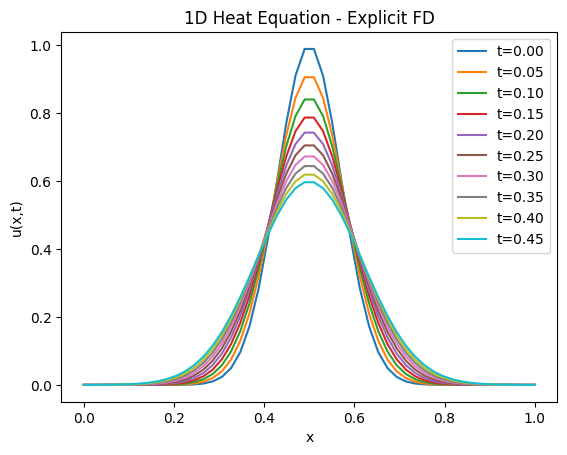

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 1.0      # length
T = 0.5      # total time
alpha = 0.01 # diffusivity
Nx = 50      # spatial points
Nt = 1000    # time steps
dx = L / (Nx - 1)
dt = T / Nt
r = alpha * dt / dx**2
if r > 0.5:
    print("Warning: unstable! r =", r)

# Initial condition: hot in middle
x = np.linspace(0, L, Nx)
u = np.exp(-((x - L/2)**2) / 0.01)  # Gaussian pulse
u[0] = u[-1] = 0  # Dirichlet BCs

# Time stepping
for n in range(Nt):
    u_new = u.copy()
    u_new[1:-1] = u[1:-1] + r * (u[2:] - 2*u[1:-1] + u[:-2])
    u = u_new
    if n % 100 == 0:  # plot every 100 steps
        plt.plot(x, u, label=f't={n*dt:.2f}')

plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('1D Heat Equation - Explicit FD')
plt.legend()
plt.show()




Run this (or similar) to see diffusion in action!

Next session: More schemes (implicit, Crank-Nicolson), higher dimensions, and limitations of these methods—setting the stage for why PINNs are revolutionary.

## Reading 

Review any undergraduate mathematical methods notes on these PDEs (your own are best if you have them). Optional: Chapter 1-2 of *Partial Differential Equations for Scientists and Engineers* by Stanley J.Farlow.